In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('./3 Global-scale Check-in Dataset'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

./3 Global-scale Check-in Dataset\dataset_TIST2015_Checkins.txt
./3 Global-scale Check-in Dataset\dataset_TIST2015_Cities.txt
./3 Global-scale Check-in Dataset\dataset_TIST2015_POIs.txt
./3 Global-scale Check-in Dataset\dataset_TIST2015_readme.txt


In [2]:
import pandas as pd
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from datetime import datetime, timedelta
import math
print("Setup Complete")

Setup Complete


In [3]:
def date_convert(date_to_convert):
    pru = datetime.datetime.strptime(date_to_convert, '%a %b %d %H:%M:%S +0000 %Y')+ datetime.timedelta(hours=-240//60)
    return pru.strftime('%b %d %Y %H:%M:%S')

def tzo_convert(tzo_to_convert):
    return  timedelta(hours=tzo_to_convert/60)

# Path of the file to read
global_filepath = "./3 Global-scale Check-in Dataset/dataset_TIST2015_Checkins.txt"
custom_date_parser = lambda x: datetime.strptime(x, "%a %b %d %H:%M:%S +0000 %Y")

# Read the file into a variable nyc_data
global_data = pd.read_table(global_filepath,names=['userId', 'venueId', 'utcTimestamp', 'timezoneOffset'])
global_data['utcTimestamp'] = pd.to_datetime(global_data['utcTimestamp'], format='%a %b %d %H:%M:%S +0000 %Y')
# global_data['timezoneOffset'] = pd.to_numeric(global_data['timezoneOffset'])
global_data.head()


,userId,venueId,utcTimestamp,timezoneOffset
0,50756,4f5e3a72e4b053fd6a4313f6,2012-04-03 18:00:06,240
1,190571,4b4b87b5f964a5204a9f26e3,2012-04-03 18:00:07,180
2,221021,4a85b1b3f964a520eefe1fe3,2012-04-03 18:00:08,-240
3,66981,4b4606f2f964a520751426e3,2012-04-03 18:00:08,-300
4,21010,4c2b4e8a9a559c74832f0de2,2012-04-03 18:00:09,240


In [4]:
from datetime import time
#ajusto la hora con el timezoneoffset
global_data["utcTimestampOffset"] = global_data.utcTimestamp + global_data.timezoneOffset.apply(tzo_convert)
#block of time
global_data_time = global_data.utcTimestampOffset.dt.time 
morning_start = time(8,0,0)
noon_start = time(11,30,0)
afternoon_start = time(14,0,0)
night_start = time(17,30,0)
rest_start = time(22,0,0)
global_data["blockofday"] = global_data_time.apply(lambda x: 0 if x >= morning_start and x < noon_start else 1 if x >= noon_start and x < afternoon_start else 2 if x >= afternoon_start and x < night_start else 3 if x >= night_start and x < rest_start else 4)
#day of week
global_data["dayofweek"] = global_data.utcTimestampOffset.dt.weekday 
#is weekday?
global_data["isweekday"] = global_data['dayofweek'].apply(lambda x: 1 if x <= 4 else 0)
global_data.head()


,userId,venueId,utcTimestamp,timezoneOffset,utcTimestampOffset,blockofday,dayofweek,isweekday
0,50756,4f5e3a72e4b053fd6a4313f6,2012-04-03 18:00:06,240,2012-04-03 22:00:06,4,1,1
1,190571,4b4b87b5f964a5204a9f26e3,2012-04-03 18:00:07,180,2012-04-03 21:00:07,3,1,1
2,221021,4a85b1b3f964a520eefe1fe3,2012-04-03 18:00:08,-240,2012-04-03 14:00:08,2,1,1
3,66981,4b4606f2f964a520751426e3,2012-04-03 18:00:08,-300,2012-04-03 13:00:08,1,1,1
4,21010,4c2b4e8a9a559c74832f0de2,2012-04-03 18:00:09,240,2012-04-03 22:00:09,4,1,1


In [7]:
import pandas as pd
# Path of the file to read
POI_filepath = "./3 Global-scale Check-in Dataset/dataset_TIST2015_POIs.txt"

POI_data = pd.read_table(POI_filepath,names=['venueId', 'longtitude', 'latitude', 'category', 'country'], encoding="latin-1")
# global_data['timezoneOffset'] = pd.to_numeric(global_data['timezoneOffset'])
POI_data.head()



,venueId,longtitude,latitude,category,country
0,3fd66200f964a52000e71ee3,40.733596,-74.003139,Jazz Club,US
1,3fd66200f964a52000e81ee3,40.758102,-73.975734,Gym,US
2,3fd66200f964a52000ea1ee3,40.732456,-74.003755,Indian Restaurant,US
3,3fd66200f964a52000ec1ee3,42.345907,-71.087001,Indian Restaurant,US
4,3fd66200f964a52000ee1ee3,39.933178,-75.159262,Sandwich Place,US


In [8]:
merged_data = pd.merge(global_data, POI_data, on='venueId', how='left')
merged_data


,userId,venueId,utcTimestamp,timezoneOffset,utcTimestampOffset,blockofday,dayofweek,isweekday,longtitude,latitude,category,country
0,50756,4f5e3a72e4b053fd6a4313f6,2012-04-03 18:00:06,240,2012-04-03 22:00:06,4,1,1,55.696132,37.557842,Comedy Club,RU
1,190571,4b4b87b5f964a5204a9f26e3,2012-04-03 18:00:07,180,2012-04-03 21:00:07,3,1,1,41.029717,28.974420,Other Great Outdoors,TR
2,221021,4a85b1b3f964a520eefe1fe3,2012-04-03 18:00:08,-240,2012-04-03 14:00:08,2,1,1,40.748939,-73.992280,Coffee Shop,US
3,66981,4b4606f2f964a520751426e3,2012-04-03 18:00:08,-300,2012-04-03 13:00:08,1,1,1,30.270753,-97.752936,Office,US
4,21010,4c2b4e8a9a559c74832f0de2,2012-04-03 18:00:09,240,2012-04-03 22:00:09,4,1,1,59.941041,30.308104,Bridge,RU
...,...,...,...,...,...,...,...,...,...,...,...,...
3972762,238462,4b243a7df964a520356424e3,2012-05-11 07:33:25,540,2012-05-11 16:33:25,2,4,1,35.729865,139.710956,Train Station,JP
3972763,83263,4b4479a4f964a5205ef525e3,2012-05-11 07:33:25,420,2012-05-11 14:33:25,2,4,1,-6.125748,106.656475,Airport,ID
3972764,97995,4b5be6e4f964a520741c29e3,2012-05-11 07:33:26,480,2012-05-11 15:33:26,2,4,1,4.613131,101.118206,Mall,MY
3972765,181337,4ecff36d30f81894adca31ba,2012-05-11 07:33:26,240,2012-05-11 11:33:26,1,4,1,55.714756,37.530228,Home (private),RU


<AxesSubplot:xlabel='dayofweek,blockofday'>

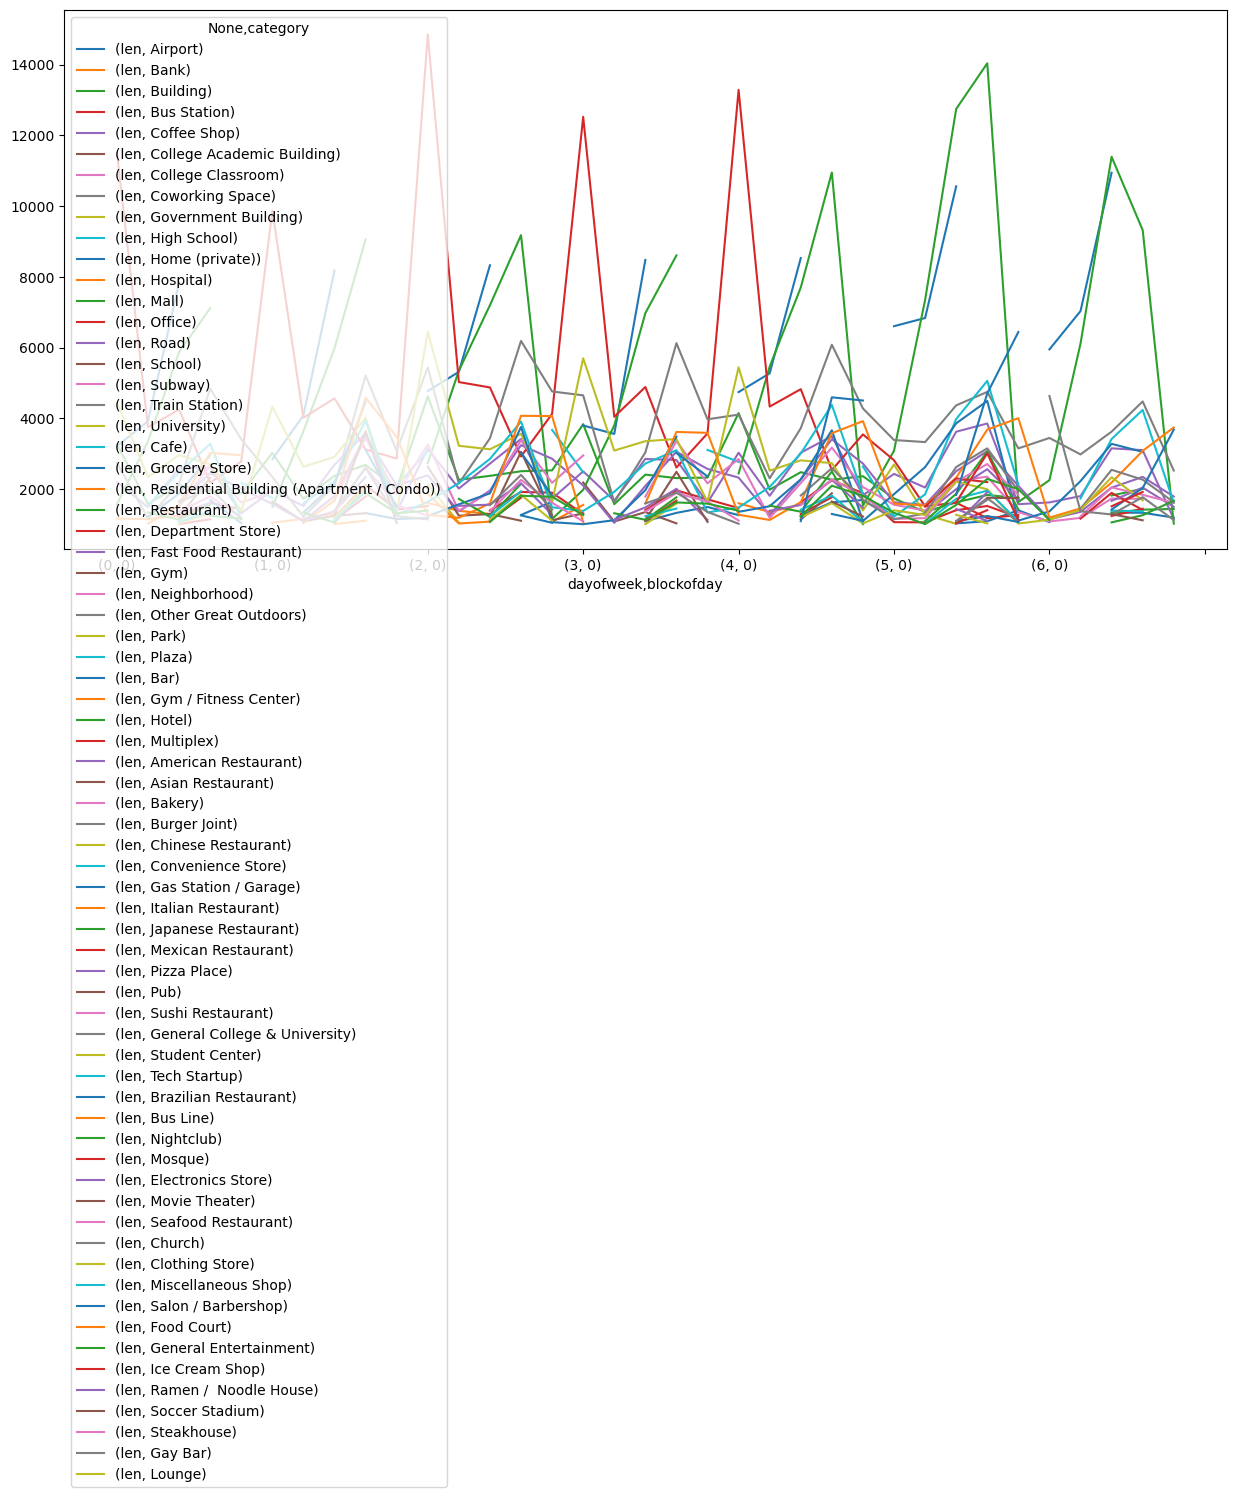

In [36]:
fig, ax = plt.subplots(figsize=(15,7))
# merged_data= merged_data[merged_data['category']!="Home (private)"]
pru = merged_data.groupby([ 'dayofweek','blockofday','category']).venueId.agg([len])
# pru['percent'] = pru.groupby(['dayofweek','blockofday'])['len'].apply(lambda x: x / float(x.sum()))
pru2 =pru.query('len > 1000 and len<15000')
pru2.unstack().plot(ax=ax)

In [1]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 计算每个标签下出现的频次
pru3 = merged_data.groupby([ 'isweekday','blockofday','category']).venueId.agg([len])
label_freq = pru3.reset_index().groupby(['isweekday', 'blockofday'])['category', 'len'].apply(lambda x: x.set_index('category')['len'].to_dict()).to_dict()

# 生成词云
for label, freq_dict in label_freq.items():
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='tab10').generate_from_frequencies(freq_dict)
    
    # 绘制词云
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.set_title(f'WordCloud of {label}')
    ax.axis('off')
    plt.show()

NameError: name 'merged_data' is not defined

## 处理profile

In [11]:
pru= nyc_data.groupby([ 'dayweek','venueCategory']).venueId.agg([len])
pru2 =pru.query('len > 500')
pru2

NameError: name 'nyc_data' is not defined